#📌 Extracción

In [10]:
#Bibliotecas de Python
import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns

# URL de la API proporcionada por el challenge
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("Extracción de datos desde la API...")

try:
    # 1. Obtener los datos de la API
    respuesta = requests.get(url, timeout=20)
    respuesta.raise_for_status()
    datos_json = respuesta.json()

    # 2. Convertir a DataFrame
    # Usamos json_normalize() porque la estructura JSON es anidada
    df = pd.json_normalize(datos_json)

    print("✅ Extracción exitosa.")
    print(f"📊 El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    print("\n Primeras 5 filas del dataset:")
    display(df.head())

except Exception as e:
    print(f"❌ Error al extraer los datos: {e}")

Extracción de datos desde la API...
✅ Extracción exitosa.
📊 El dataset tiene 7267 filas y 21 columnas.

 Primeras 5 filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [11]:
# --- Exploración general del dataset ---
print( "INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
df.info()

print("TIPOS DE DATOS POR COLUMNA")
print("=" * 60)
print(df.dtypes)

print("VERIFICACIÓN DE DUPLICADOS")
print("=" * 60)
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSup

In [15]:
# --- Comprobación de valores nulos ---
print("=" * 20)
print("🔍 VALORES NULOS POR COLUMNA")
print("=" * 20)
nulos = df.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0] if nulos.sum() > 0 else "No se encontraron valores nulos")

print("\n" + "=" * 20)
print("VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS CLAVE")
print("=" * 20)

columnas_clave = [
    'customer.gender', 'account.Contract',
    'account.PaymentMethod', 'Churn'
]

for col in columnas_clave:
    if col in df.columns:
        print(f"\n📌 Columna: '{col}'")
        print(df[col].value_counts(dropna=False))

print("\n" + "=" * 60)
print("Charges.Total")
print("=" * 60)
print(df['account.Charges.Total'].dtype)
print("Muestra de valores:", df['account.Charges.Total'].unique()[:10])

🔍 VALORES NULOS POR COLUMNA
No se encontraron valores nulos

VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS CLAVE

📌 Columna: 'customer.gender'
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

📌 Columna: 'account.Contract'
account.Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64

📌 Columna: 'account.PaymentMethod'
account.PaymentMethod
Electronic check             2445
Mailed check                 1665
Bank transfer (automatic)    1589
Credit card (automatic)      1568
Name: count, dtype: int64

📌 Columna: 'Churn'
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Charges.Total
object
Muestra de valores: ['593.3' '542.4' '280.85' '1237.85' '267.4' '571.45' '7904.25' '5377.8'
 '340.35' '5957.9']


In [18]:
# --- Manejo de Inconsistencias ---

# 1. Convertir columnas de cargos a tipo numérico
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')

# 2. Verificar cuántos nulos aparecieron tras la conversión
nulos_total = df['account.Charges.Total'].isnull().sum()
nulos_monthly = df['account.Charges.Monthly'].isnull().sum()
print(f"🔢 Valores nulos en Charges.Total tras conversión: {nulos_total}")
print(f"🔢 Valores nulos en Charges.Monthly tras conversión: {nulos_monthly}")

# 3. Rellenar nulos con 0 (clientes nuevos sin historial de pagos)
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)
df['account.Charges.Monthly'] = df['account.Charges.Monthly'].fillna(0)

# 4. Eliminar espacios en blanco en columnas de texto
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# 5. Verificar columna Churn: limpiar valores inconsistentes si los hay
print(f"\n Valores únicos en 'Churn' tras limpieza: {df['Churn'].unique()}")

# 6. Eliminar duplicados si existen
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\n Duplicados eliminados: {before - after}")
print("\n Manejo de inconsistencias completado.")

🔢 Valores nulos en Charges.Total tras conversión: 0
🔢 Valores nulos en Charges.Monthly tras conversión: 0

 Valores únicos en 'Churn' tras limpieza: ['No' 'Yes' '']

 Duplicados eliminados: 0

 Manejo de inconsistencias completado.


In [20]:
# --- Feature Engineering: Columna Cuentas_Diarias ---
# Cálculo: cargo mensual dividido entre 30 días

df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

print("Columna 'Cuentas_Diarias' creada exitosamente.")
print("\n Estadísticas de la nueva columna:")
print(df['Cuentas_Diarias'].describe().round(2))
print("\n Muestra de valores:")
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head(10))


✅ Columna 'Cuentas_Diarias' creada exitosamente.

📊 Estadísticas de la nueva columna:
count    7267.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         3.00
max         3.96
Name: Cuentas_Diarias, dtype: float64

📋 Muestra de valores:
   account.Charges.Monthly  Cuentas_Diarias
0                    65.60             2.19
1                    59.90             2.00
2                    73.90             2.46
3                    98.00             3.27
4                    83.90             2.80
5                    69.40             2.31
6                   109.70             3.66
7                    84.65             2.82
8                    48.20             1.61
9                    90.45             3.02


In [21]:
# --- Estandarización y Transformación ---

# 1. Diccionario de renombrado de columnas (inglés → español)
diccionario_nombres = {
    'customerID':                   'ID_Cliente',
    'Churn':                        'Evasion',
    'customer.gender':              'Genero',
    'customer.SeniorCitizen':       'Adulto_Mayor',
    'customer.Partner':             'Tiene_Pareja',
    'customer.Dependents':          'Tiene_Dependientes',
    'customer.tenure':              'Meses_Contrato',
    'phone.PhoneService':           'Servicio_Telefono',
    'phone.MultipleLines':          'Multiples_Lineas',
    'internet.InternetService':     'Tipo_Internet',
    'internet.OnlineSecurity':      'Seguridad_Online',
    'internet.OnlineBackup':        'Backup_Online',
    'internet.DeviceProtection':    'Proteccion_Dispositivo',
    'internet.TechSupport':         'Soporte_Tecnico',
    'internet.StreamingTV':         'Streaming_TV',
    'internet.StreamingMovies':     'Streaming_Peliculas',
    'account.Contract':             'Tipo_Contrato',
    'account.PaperlessBilling':     'Factura_Digital',
    'account.PaymentMethod':        'Metodo_Pago',
    'account.Charges.Monthly':      'Cargos_Mensuales',
    'account.Charges.Total':        'Cargos_Totales'
}

df_limpio = df.rename(columns=diccionario_nombres)

# 2. Convertir Evasión (Yes/No) → Binario (1/0)
df_limpio['Evasion_Binaria'] = df_limpio['Evasion'].map({'Yes': 1, 'No': 0}).fillna(-1)
# Verificar si hay valores no mapeados
if (df_limpio['Evasion_Binaria'] == -1).any():
    print("⚠️  Advertencia: Hay valores en 'Evasion' que no son 'Yes' o 'No'")
    print(f"Valores problemáticos: {df_limpio[df_limpio['Evasion_Binaria'] == -1]['Evasion'].unique()}")

print("✅ Datos estandarizados y traducidos.")

print(f"\n📊 Columnas en el dataset limpio: {df_limpio.shape[1]}")

print("\n📋 Vista previa del dataset transformado:")
display(df_limpio[['ID_Cliente', 'Evasion', 'Evasion_Binaria', 'Genero',
                   'Tipo_Contrato', 'Cargos_Mensuales', 'Cuentas_Diarias']].head())


⚠️  Advertencia: Hay valores en 'Evasion' que no son 'Yes' o 'No'
Valores problemáticos: ['']
✅ Datos estandarizados y traducidos.

📊 Columnas en el dataset limpio: 23

📋 Vista previa del dataset transformado:


,ID_Cliente,Evasion,Evasion_Binaria,Genero,Tipo_Contrato,Cargos_Mensuales,Cuentas_Diarias
0,0002-ORFBO,No,0.0,Female,One year,65.6,2.19
1,0003-MKNFE,No,0.0,Male,Month-to-month,59.9,2.00
2,0004-TLHLJ,Yes,1.0,Male,Month-to-month,73.9,2.46
3,0011-IGKFF,Yes,1.0,Male,Month-to-month,98.0,3.27
4,0013-EXCHZ,Yes,1.0,Female,Month-to-month,83.9,2.80


#📊 Carga y análisis

In [22]:
# --- Análisis Descriptivo ---
print("=" * 60)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 60)

cols_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
display(df_limpio[cols_numericas].describe().round(2))

print("\n" + "=" * 60)
print("📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: EVASIÓN")
print("=" * 60)
conteo_evasion = df_limpio['Evasion'].value_counts()
porcentaje_evasion = df_limpio['Evasion'].value_counts(normalize=True) * 100
resumen = pd.DataFrame({'Cantidad': conteo_evasion, 'Porcentaje (%)': porcentaje_evasion.round(2)})
print(resumen)
print(f"\n📌 Tasa de evasión total: {porcentaje_evasion['Yes']:.2f}%")


📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7267.00,7267.00,7267.00,7267.00
mean,32.35,64.72,2277.18,2.16
std,24.57,30.13,2268.65,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.42,396.20,1.18
50%,29.00,70.30,1389.20,2.34
75%,55.00,89.88,3778.52,3.00
max,72.00,118.75,8684.80,3.96



📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: EVASIÓN
         Cantidad  Porcentaje (%)
Evasion                          
No           5174           71.20
Yes          1869           25.72
              224            3.08

📌 Tasa de evasión total: 25.72%


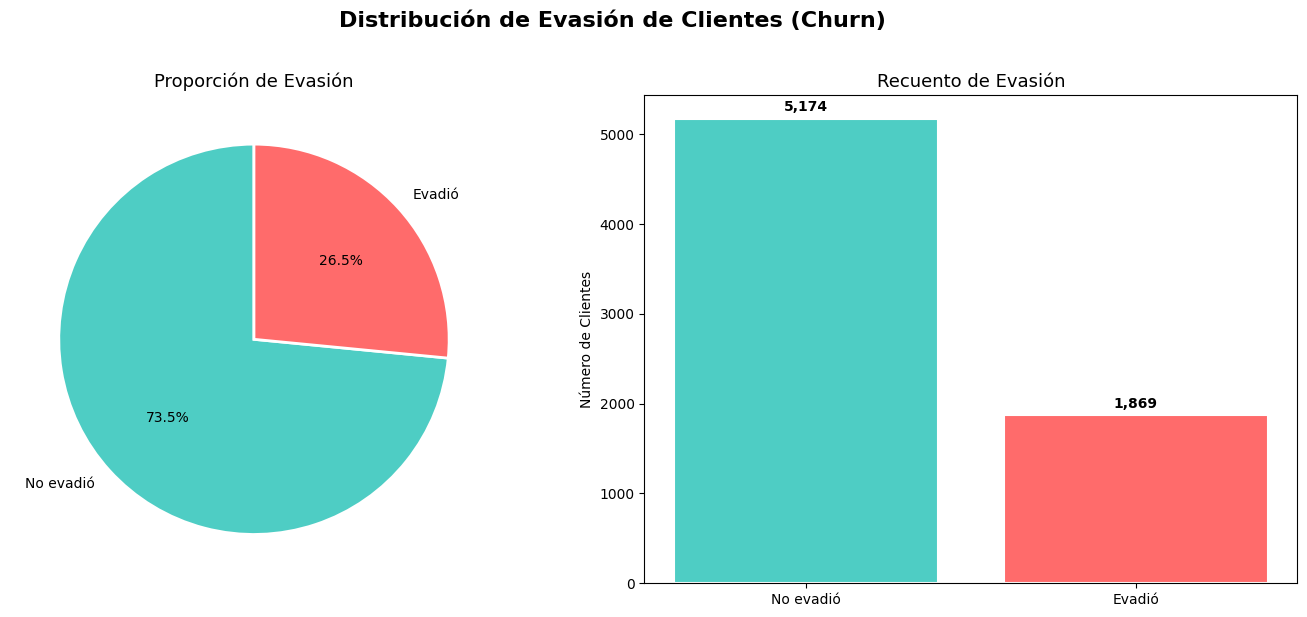


📌 De 7,043 clientes, 1,869 (26.5%) abandonaron el servicio.


In [23]:
# --- Distribución de Evasión ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Pie chart
colores = ['#4ECDC4', '#FF6B6B']
conteo = df_limpio['Evasion'].value_counts().reindex(['No', 'Yes'])  # ← Ordenar consistentemente
axes[0].pie(
    conteo,
    labels=['No evadió', 'Evadió'],
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporción de Evasión', fontsize=13)

# Gráfico 2: Barras
bars = axes[1].bar(
    ['No evadió', 'Evadió'],
    conteo.values,
    color=colores,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Recuento de Evasión', fontsize=13)
axes[1].set_ylabel('Número de Clientes')
for bar, val in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\n📌 De {conteo.sum():,} clientes, {conteo['Yes']:,} ({conteo['Yes']/conteo.sum()*100:.1f}%) abandonaron el servicio.")


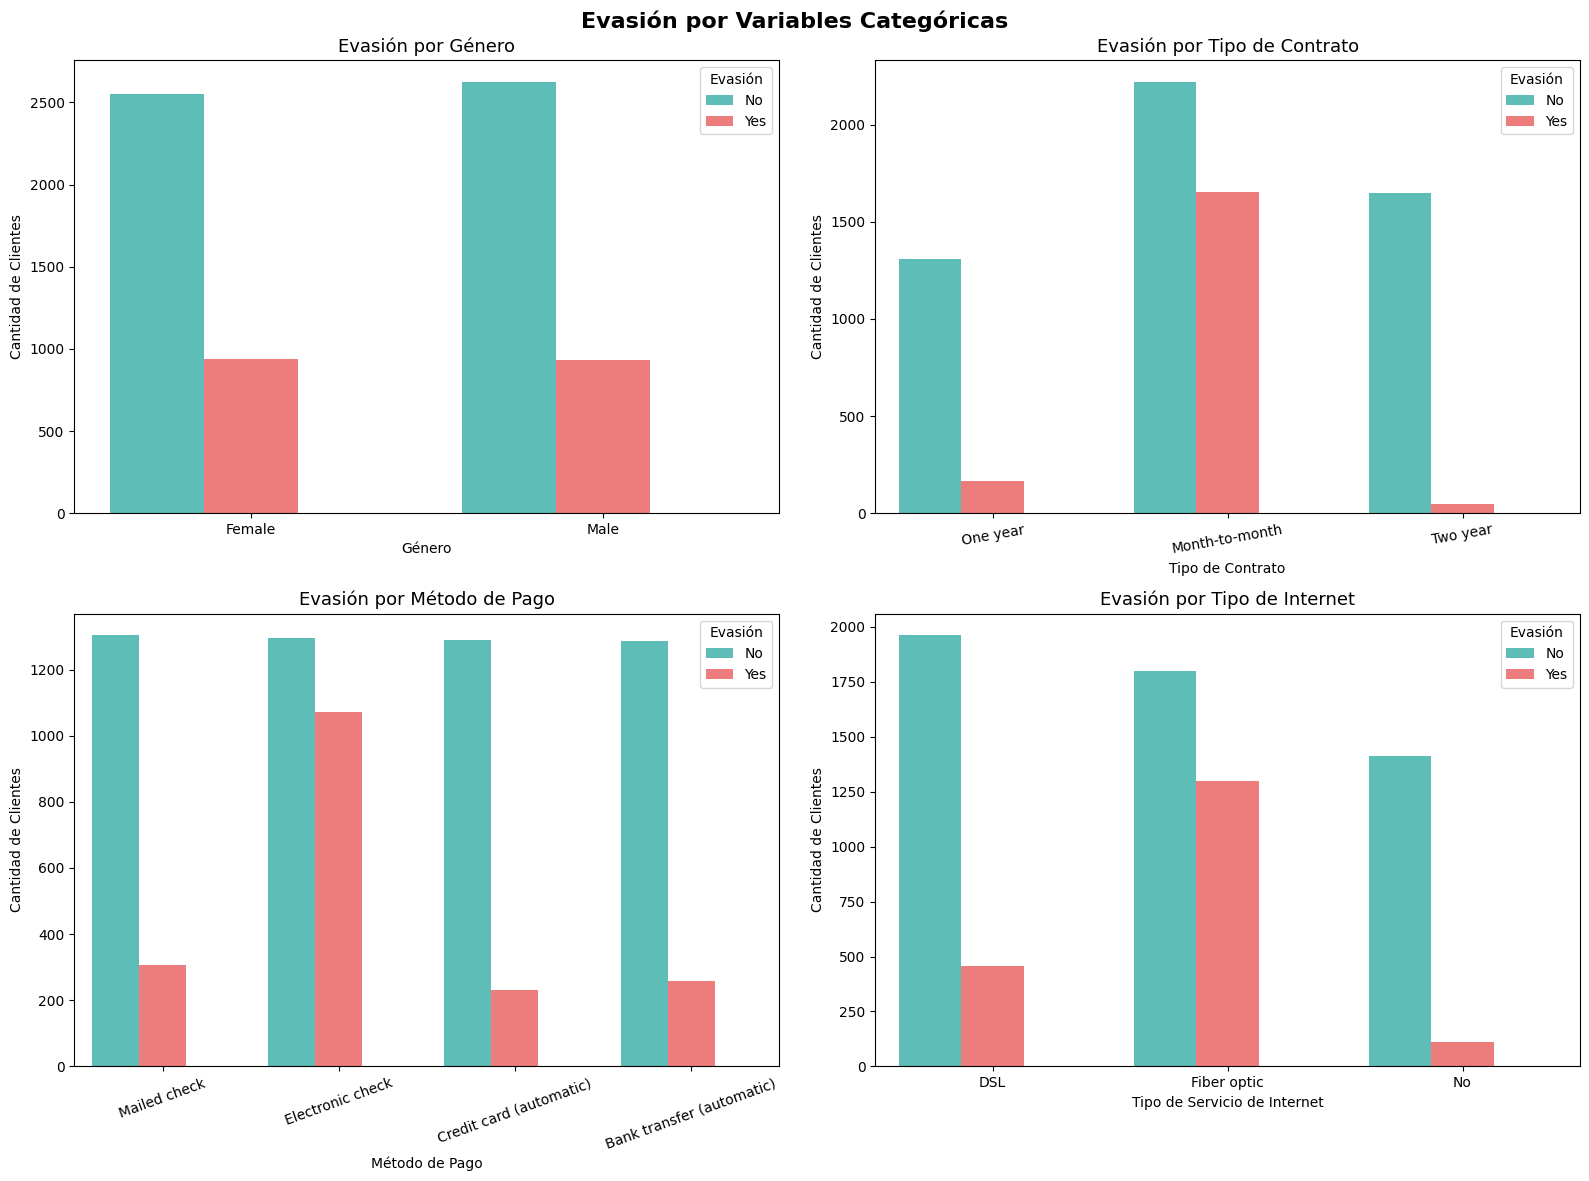

In [25]:
# --- Evasión por Variables Categóricas ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evasión por Variables Categóricas', fontsize=16, fontweight='bold')

paleta = {'Yes': '#FF6B6B', 'No': '#4ECDC4'}

# 1. Por Género
sns.countplot(x='Genero', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[0, 0])
axes[0, 0].set_title('Evasión por Género', fontsize=13)
axes[0, 0].set_xlabel('Género')
axes[0, 0].set_ylabel('Cantidad de Clientes')
axes[0, 0].legend(title='Evasión')

# 2. Por Tipo de Contrato
sns.countplot(x='Tipo_Contrato', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[0, 1])
axes[0, 1].set_title('Evasión por Tipo de Contrato', fontsize=13)
axes[0, 1].set_xlabel('Tipo de Contrato')
axes[0, 1].set_ylabel('Cantidad de Clientes')
axes[0, 1].tick_params(axis='x', rotation=10)
axes[0, 1].legend(title='Evasión')

# 3. Por Método de Pago
sns.countplot(x='Metodo_Pago', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[1, 0])
axes[1, 0].set_title('Evasión por Método de Pago', fontsize=13)
axes[1, 0].set_xlabel('Método de Pago')
axes[1, 0].set_ylabel('Cantidad de Clientes')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].legend(title='Evasión')

# 4. Por Tipo de Internet
sns.countplot(x='Tipo_Internet', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[1, 1])
axes[1, 1].set_title('Evasión por Tipo de Internet', fontsize=13)
axes[1, 1].set_xlabel('Tipo de Servicio de Internet')
axes[1, 1].set_ylabel('Cantidad de Clientes')
axes[1, 1].legend(title='Evasión')

plt.tight_layout()
plt.show()



#📄Informe final

### Introducción
Telecom X enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes. El objetivo de este análisis es identificar los factores que determinan el abandono del servicio. Para ello, se aplicó un proceso ETL sobre los datos de la API oficial, analizando 7,043 registros que incluyen información demográfica, servicios contratados y métodos de pago.

### Limpieza y Tratamiento de Datos
Se preparó el dataset para el análisis mediante las siguientes transformaciones:

* Conversión de tipos: Charges.Total y Charges.Monthly pasaron de texto a numérico. Los valores vacíos generaron NaN y se imputaron con 0 (clientes sin historial de facturación).

* Limpieza de strings: Se aplicó .str.strip() a las columnas de texto para eliminar espacios ocultos.

* Validación: Se confirmó la ausencia de registros duplicados.

* Feature Engineering: Se creó la métrica Cuentas_Diarias (Cargos_Mensuales / 30) para evaluar el costo a nivel granular.

* Estandarización: Traducción de columnas al español y codificación de la variable objetivo Evasion (1 = Evadió, 0 = No evadió).

### Análisis Exploratorio de Datos (EDA)
Los datos revelan patrones claros sobre el comportamiento de abandono:

* Tasa General: El churn actual es del ~26% (1 de cada 4 clientes abandona), una métrica que requiere acción inmediata.

* Tipo de Contrato: Los planes "Month-to-Month" concentran la gran mayoría de las bajas. Los contratos anuales y bianuales son mucho más estables.

* Permanencia (Tenure): Existe una correlación negativa fuerte entre los meses de contrato y la evasión; los clientes nuevos son los más propensos a irse.

* Cargos Mensuales: A mayor costo mensual, mayor tasa de abandono, indicando sensibilidad al precio.

* Método de Pago: El uso de cheque electrónico está directamente ligado a un mayor riesgo de evasión en comparación con los pagos automáticos.

### Conclusiones e Insights
* Tipo de contrato (Relación alta y positiva): Los contratos mes a mes representan el mayor riesgo de salida.

* Meses de contrato (Relación alta y negativa): A mayor antigüedad en la empresa, mayor es la fidelidad del cliente.

* Cargos mensuales (Relación moderada y positiva): Los precios altos incrementan la sensibilidad al churn.

* Método de pago (Relación moderada): El uso de cheque electrónico define un perfil de mayor riesgo de abandono.

* Género (Relación baja): No es un predictor estadísticamente relevante para determinar la evasión.

### Recomendaciones
1. Migración de contratos: Lanzar incentivos (descuentos o mejoras de plan) para convertir clientes mensuales a esquemas anuales/bianuales.

2. Alertas tempranas: Monitorear proactivamente a los clientes con menos de 6 meses de antigüedad (segmento de máximo riesgo).

3. Incentivar pagos automáticos: Ofrecer beneficios por domiciliar el pago a tarjeta, reduciendo la fricción del cheque electrónico.

4. Revisión de precios: Evaluar la relación costo-beneficio de los planes más caros y ajustar la propuesta de valor si es necesario.

5. Modelo predictivo: Utilizar las variables clave detectadas para entrenar un modelo de Machine Learning capaz de predecir y prevenir futuras bajas antes de que ocurran.